In [2]:
import pandas as pd

In [3]:
df21 = pd.read_csv('dataset/21-22.csv')
df21

,Date,Time,HomeTeam,AwayTeam,FTR,FTHG,FTAG,Home_TablePosDiff,Home_TablePosDiff_Rolling5,Home_TablePosDiff_Rolling10,...,Fouls_Rolling5_all,Fouls_Rolling10_all,Points_Rolling5,Points_Rolling10,Points_Rolling5_all,Points_Rolling10_all,Win_Rolling5,Win_Rolling10,Win_Rolling5_all,Win_Rolling10_all
0,2021-08-28,12:30,Man City,Arsenal,H,5,0,0,0.0,0.0,...,9.0,9.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
1,2021-08-28,15:00,Aston Villa,Brentford,D,1,1,0,0.0,0.0,...,10.5,10.5,1.0,1.0,2.0,2.0,0.5,0.50,0.75,0.75
2,2021-08-28,15:00,Brighton,Everton,A,0,2,0,0.0,0.0,...,13.0,13.0,1.0,1.0,2.0,2.0,0.5,0.50,0.75,0.75
3,2021-08-28,15:00,Newcastle,Southampton,D,2,2,0,0.0,0.0,...,13.5,13.5,0.0,0.0,0.5,0.5,0.0,0.00,0.25,0.25
4,2021-08-28,15:00,Norwich,Leicester,A,1,2,0,0.0,0.0,...,7.0,7.0,0.0,0.0,1.5,1.5,0.0,0.00,0.50,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2022-05-22,16:00,Crystal Palace,Man United,H,1,0,-7,-0.6,-1.9,...,8.0,9.2,0.0,0.9,0.8,1.1,0.0,0.35,0.30,0.40
356,2022-05-22,16:00,Leicester,Southampton,H,4,1,5,3.6,-0.2,...,8.4,8.0,0.4,1.0,0.2,0.5,0.2,0.40,0.10,0.20
357,2022-05-22,16:00,Liverpool,Wolves,H,3,1,8,8.2,11.0,...,6.2,9.4,0.8,1.6,0.4,1.1,0.3,0.55,0.20,0.40
358,2022-05-22,16:00,Man City,Aston Villa,H,3,2,12,8.4,8.5,...,11.8,11.1,1.4,1.6,1.6,0.9,0.5,0.55,0.60,0.35


In [5]:
import matplotlib.pyplot as plt
import numpy as np

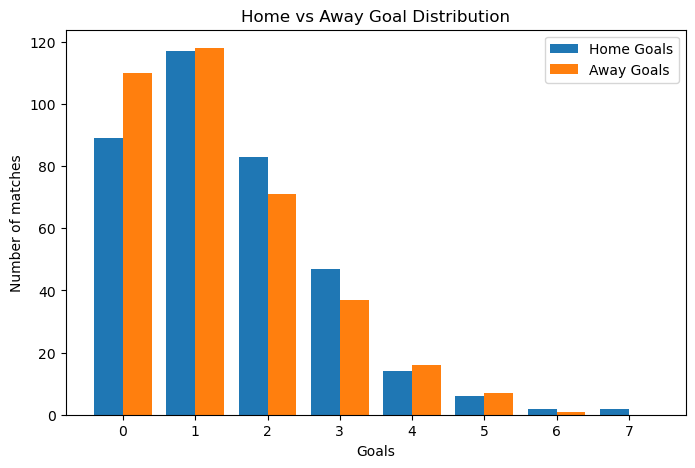

In [24]:
max_goals = max(df21['FTHG'].max(), df21['FTAG'].max())

home_counts = df21['FTHG'].value_counts().sort_index()
away_counts = df21['FTAG'].value_counts().sort_index()

x = np.arange(max_goals + 1)

plt.figure(figsize=(8,5))

plt.bar(x - 0.2,
        home_counts.reindex(x, fill_value=0),
        width=0.4,
        label='Home Goals')

plt.bar(x + 0.2,
        away_counts.reindex(x, fill_value=0),
        width=0.4,
        label='Away Goals')

plt.xticks(x)
plt.xlabel("Goals")
plt.ylabel("Number of matches")
plt.title("Home vs Away Goal Distribution")
plt.legend()

plt.show()

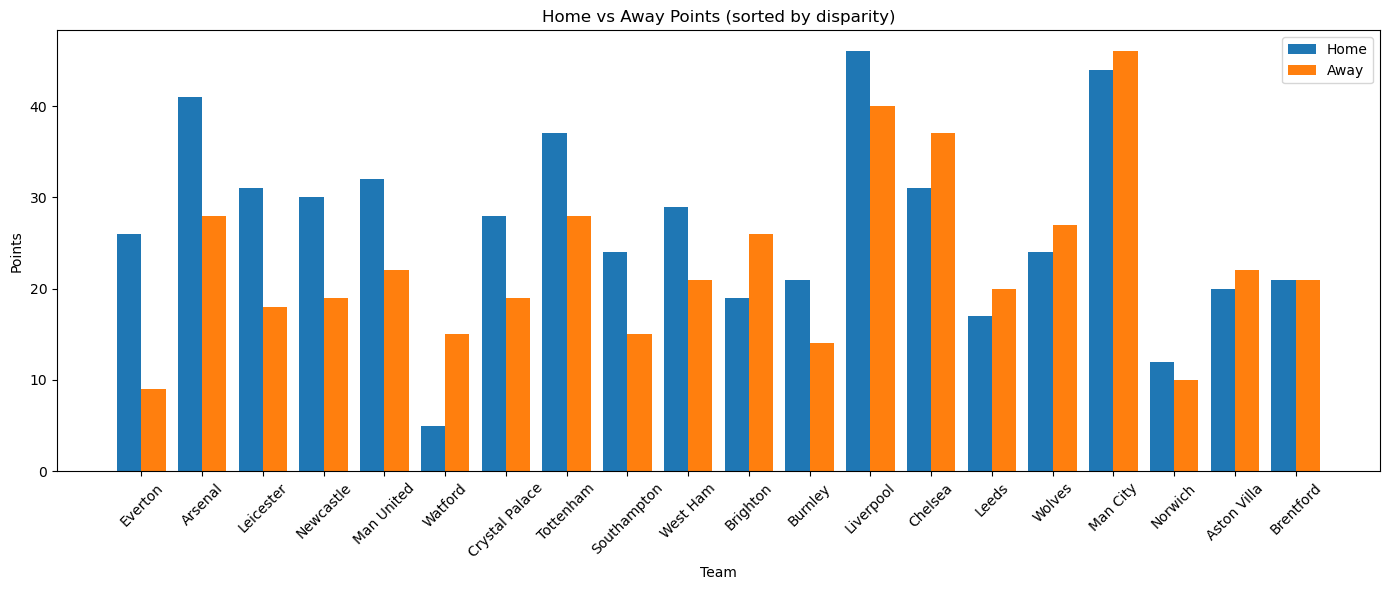

In [26]:
home = df21[['HomeTeam', 'FTR']].copy()

home['Points'] = home['FTR'].map({
    'H': 3,
    'D': 1,
    'A': 0
})

home_points = home.groupby('HomeTeam')['Points'].sum()

# ----------------------------
# Away points
# ----------------------------
away = df21[['AwayTeam', 'FTR']].copy()

away['Points'] = away['FTR'].map({
    'A': 3,
    'D': 1,
    'H': 0
})

away_points = away.groupby('AwayTeam')['Points'].sum()

# ----------------------------
# Combine
# ----------------------------
points = pd.DataFrame({
    'Home': home_points,
    'Away': away_points
}).fillna(0)

# Difference between home and away points
points['Difference'] = (points['Home'] - points['Away']).abs()

# Sort by largest disparity
points = points.sort_values('Difference', ascending=False)

# ----------------------------
# Plot
# ----------------------------
x = np.arange(len(points))
width = 0.4

plt.figure(figsize=(14,6))

plt.bar(x - width/2, points['Home'], width, label='Home')
plt.bar(x + width/2, points['Away'], width, label='Away')

plt.xticks(x, points.index, rotation=45)
plt.ylabel("Points")
plt.xlabel("Team")
plt.title("Home vs Away Points (sorted by disparity)")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Load all seasons
seasons = [
    "21-22.csv",
    "22-23.csv",
    "23-24.csv",
    "24-25.csv",
    "25-26.csv"
]

dfs = []

for season in seasons:
    df = pd.read_csv(f"dataset/{season}")
    df['Season'] = season[:5]
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

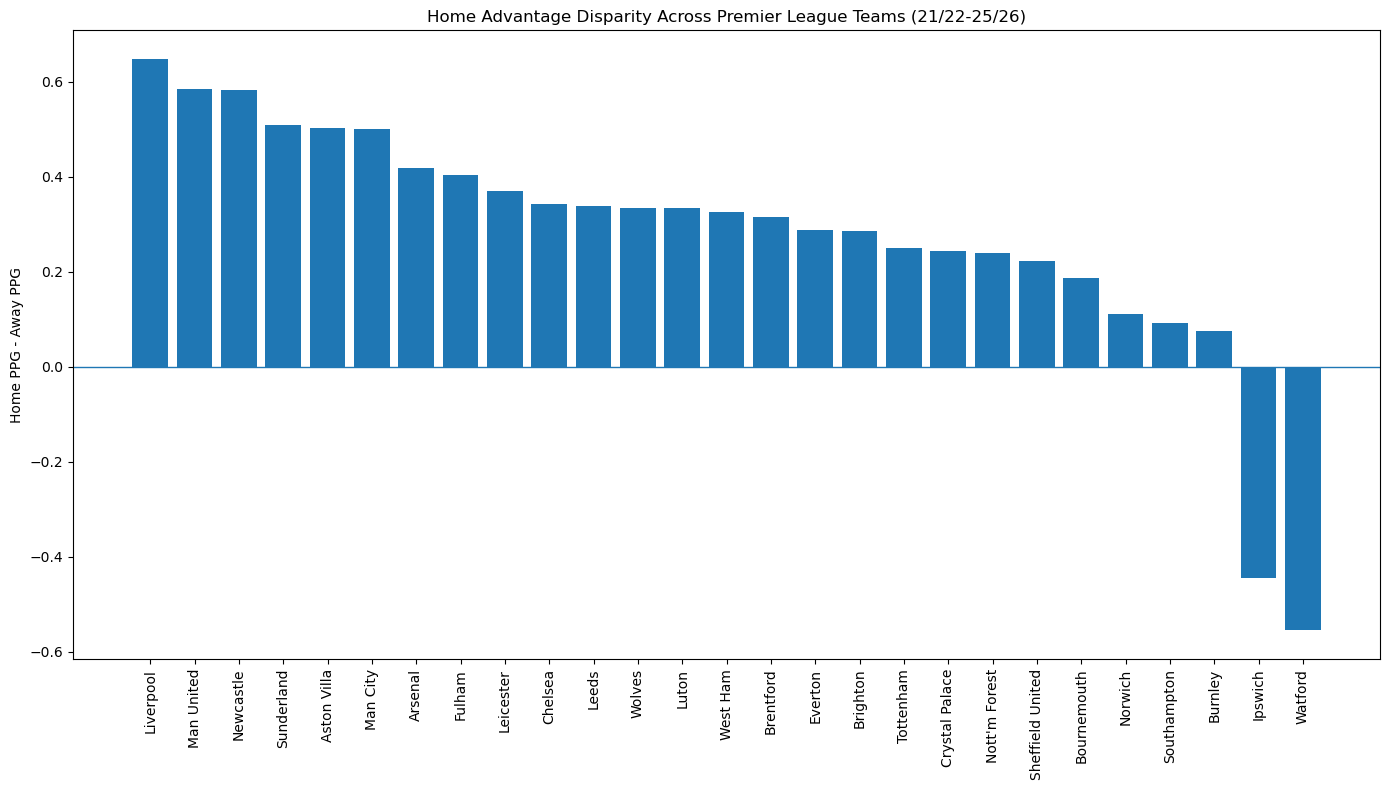

In [ ]:
# -----------------------------
# Calculate home/away points
# -----------------------------

home = pd.DataFrame({
    "Team": all_df["HomeTeam"],
    "HomePoints": all_df["FTR"].map({
        "H": 3,
        "D": 1,
        "A": 0
    }),
    "HomeGames": 1
})


away = pd.DataFrame({
    "Team": all_df["AwayTeam"],
    "AwayPoints": all_df["FTR"].map({
        "A": 3,
        "D": 1,
        "H": 0
    }),
    "AwayGames": 1
})


team_points = (
    home.groupby("Team")
    .sum()
    .join(
        away.groupby("Team").sum()
    )
)


# Points per game
team_points["HomePPG"] = (
    team_points["HomePoints"] /
    team_points["HomeGames"]
)

team_points["AwayPPG"] = (
    team_points["AwayPoints"] /
    team_points["AwayGames"]
)


# Difference
team_points["HomeAwayDifference"] = (
    team_points["HomePPG"] -
    team_points["AwayPPG"]
)


# Sort by disparity
team_points = team_points.sort_values(
    "HomeAwayDifference",
    ascending=False
)


# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(14,8))

plt.bar(
    team_points.index,
    team_points["HomeAwayDifference"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(
    rotation=90
)

plt.ylabel(
    "Home PPG - Away PPG"
)

plt.title(
    "Home Advantage Disparity Across Premier League Teams (21/22-25/26)"
)

plt.tight_layout()

plt.show()

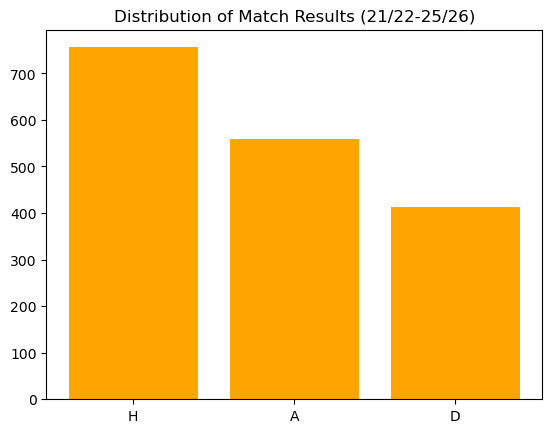

FTR
H    0.437500
A    0.324074
D    0.238426
Name: proportion, dtype: float64

In [34]:
plt.bar(all_df['FTR'].value_counts().index, all_df['FTR'].value_counts().values, color='orange')
plt.title('Distribution of Match Results (21/22-25/26)')
plt.show()
all_df["FTR"].value_counts(normalize=True)

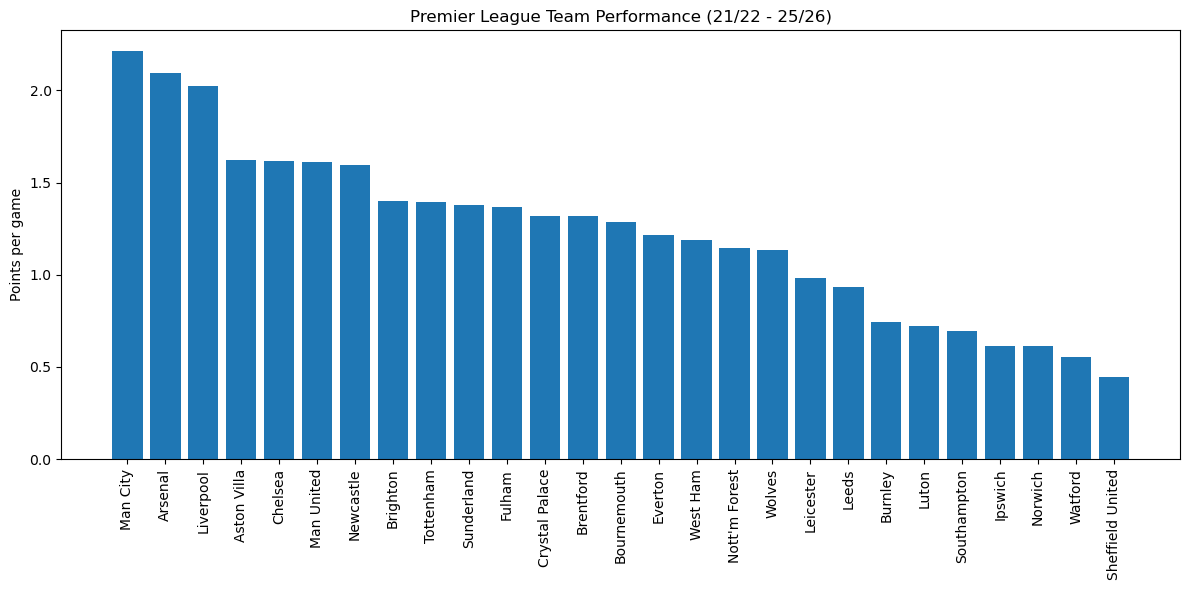

In [35]:
# Home points
home = pd.DataFrame({
    "Team": all_df["HomeTeam"],
    "Points": all_df["FTR"].map({
        "H": 3,
        "D": 1,
        "A": 0
    })
})


# Away points
away = pd.DataFrame({
    "Team": all_df["AwayTeam"],
    "Points": all_df["FTR"].map({
        "A": 3,
        "D": 1,
        "H": 0
    })
})


# Combine
team_points = pd.concat(
    [home, away],
    ignore_index=True
)


# Calculate PPG
ppg = (
    team_points
    .groupby("Team")["Points"]
    .agg(
        TotalPoints="sum",
        Games="count"
    )
)

ppg["PPG"] = ppg["TotalPoints"] / ppg["Games"]


# Sort descending
ppg = ppg.sort_values(
    "PPG",
    ascending=False
)


# Plot
plt.figure(figsize=(12,6))

plt.bar(
    ppg.index,
    ppg["PPG"]
)

plt.xticks(
    rotation=90
)

plt.ylabel(
    "Points per game"
)

plt.title(
    "Premier League Team Performance (21/22 - 25/26)"
)

plt.tight_layout()

plt.show()

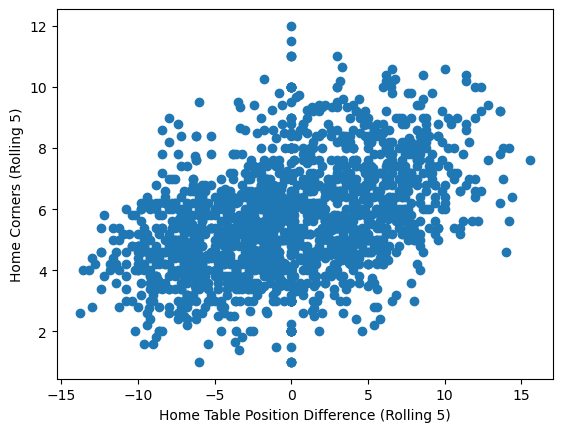

In [42]:
plt.scatter(all_df['Home_TablePosDiff_Rolling5'], all_df['Home_Corners_Rolling5'])
plt.xlabel('Home Table Position Difference (Rolling 5)')
plt.ylabel('Home Corners (Rolling 5)')
plt.show()